In [1]:
import pandas as pd

In [3]:
df=pd.read_csv("heights.csv")
df.shape

(20, 2)

In [4]:
df.head()

,name,height
0,mohan,1.2
1,maria,4.6
2,sakib,4.9
3,tao,5.1
4,virat,5.2


In [11]:
df.describe()

,height
count,20.000000
mean,7.305000
std,7.839003
min,1.200000
25%,5.350000
50%,5.700000
75%,6.275000
max,40.200000


In [12]:
df[df.height>6.27]

,name,height
15,johnson,6.5
16,donald,6.6
17,aamir,7.1
18,ken,7.1
19,Liu,40.2


In [6]:
Q1,Q3=df["height"].quantile(0.25),df["height"].quantile(0.75)
Q1,Q3

(np.float64(5.3500000000000005), np.float64(6.275))

In [7]:
IQR=Q3-Q1
IQR

np.float64(0.9249999999999998)

In [8]:
lower=Q1-(1.5)*IQR
upper=Q3+(1.5)*IQR
lower,upper

(np.float64(3.962500000000001), np.float64(7.6625))

In [10]:
df_new=df[(df["height"] > lower) & (df["height"] < upper)]
df_new

,name,height
1,maria,4.6
2,sakib,4.9
3,tao,5.1
4,virat,5.2
5,khusbu,5.4
6,dmitry,5.5
7,selena,5.5
8,john,5.6
9,imran,5.6
10,jose,5.8


#### Using Box Plot


In [14]:
!pip install openpyxl

In [15]:
df=pd.read_excel("region_wise_sales.xlsx")

In [16]:
df.head()

,Month,Year,Region,Sales
0,January,2022,APAC,36750
1,February,2022,APAC,36995
2,March,2022,APAC,18579
3,April,2022,APAC,37768
4,May,2022,APAC,23956


In [18]:
df.Region.unique()

array(['APAC', 'Europe', 'Americas'], dtype=object)

In [19]:
df_apac=df[df['Region']=="APAC"]

In [23]:
df_europe=df[df['Region']=="Europe"]

In [24]:
df_americas=df[df['Region']=="Americas"]

In [25]:
df_apac.head()

,Month,Year,Region,Sales
0,January,2022,APAC,36750
1,February,2022,APAC,36995
2,March,2022,APAC,18579
3,April,2022,APAC,37768
4,May,2022,APAC,23956


In [26]:
df_europe.head()

,Month,Year,Region,Sales
12,January,2022,Europe,9665
13,February,2022,Europe,10297
14,March,2022,Europe,11079
15,April,2022,Europe,13410
16,May,2022,Europe,11229


In [29]:
def finding_IQR(data):
    Q1,Q3=data.Sales.quantile([0.25,0.75])
    IQR=Q3-Q1
    lower=Q1-(1.5)*IQR
    upper=Q3+(1.5)*IQR
    return lower,upper
    

In [30]:
lower, upper=finding_IQR(df_apac)

In [31]:
lower,upper

(-737.125, 59747.875)

In [32]:
df_apac.describe()

,Year,Sales
count,12.0,12.000000
mean,2022.0,29762.166667
std,0.0,7725.522905
min,2022.0,18579.000000
25%,2022.0,21944.750000
50%,2022.0,31215.500000
75%,2022.0,37066.000000
max,2022.0,38143.000000


In [33]:
lower, upper=finding_IQR(df_europe)
lower,upper

(7306.875, 17665.875)

In [34]:
df_europe.describe()

,Year,Sales
count,12.0,12.000000
mean,2022.0,13147.583333
std,0.0,3549.568795
min,2022.0,9665.000000
25%,2022.0,11191.500000
50%,2022.0,12044.000000
75%,2022.0,13781.250000
max,2022.0,23000.000000


In [37]:
df_europe[df_europe["Sales"] > 17665]

,Month,Year,Region,Sales
21,October,2022,Europe,23000


In [38]:
df_europe_new=df_europe[(df_europe["Sales"]> 7206) & (df_europe["Sales"] < 17665) ]
df_europe_new

,Month,Year,Region,Sales
12,January,2022,Europe,9665
13,February,2022,Europe,10297
14,March,2022,Europe,11079
15,April,2022,Europe,13410
16,May,2022,Europe,11229
17,June,2022,Europe,15352
18,July,2022,Europe,13286
19,August,2022,Europe,11470
20,September,2022,Europe,11873
22,November,2022,Europe,12215


In [44]:
df_europe.loc[21]

Month     October
Year         2022
Region     Europe
Sales       23000
Name: 21, dtype: object

In [45]:
df_europe_new.loc[21]

KeyError: 21

In [46]:
labels=df.Region.unique()
labels

array(['APAC', 'Europe', 'Americas'], dtype=object)

In [49]:
plot_data=[df["Sales"][df["Region"] == label] for label in labels]
plot_data

[0     36750
 1     36995
 2     18579
 3     37768
 4     23956
 5     38143
 6     29132
 7     21961
 8     33299
 9     37279
 10    21388
 11    21896
 Name: Sales, dtype: int64,
 12     9665
 13    10297
 14    11079
 15    13410
 16    11229
 17    15352
 18    13286
 19    11470
 20    11873
 21    23000
 22    12215
 23    14895
 Name: Sales, dtype: int64,
 24    30247
 25    29284
 26    27904
 27    23407
 28    23716
 29    25077
 30    33649
 31    24560
 32    34102
 33    28257
 34    30691
 35    29387
 Name: Sales, dtype: int64]

C:\Users\rushi\AppData\Local\Temp\ipykernel_13336\253774911.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=labels,patch_artist=True)


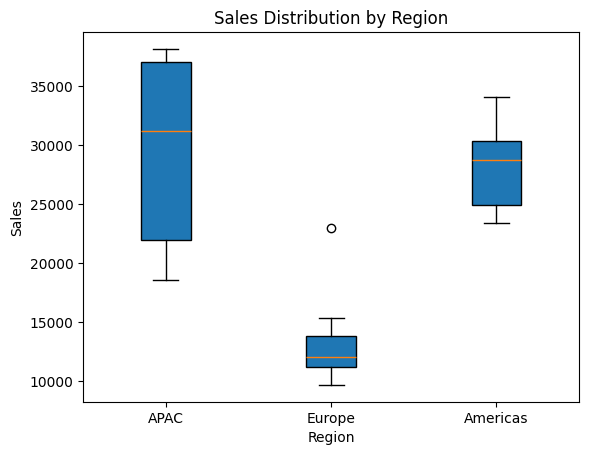

In [54]:
import matplotlib.pyplot as plt

plt.boxplot(plot_data, labels=labels,patch_artist=True)

plt.title("Sales Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()